# Brain Tumor MRI Classification - CNN
This notebook focuses on classifying brain tumor MRI images using a Convolutional Neural Network.

In [38]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42
IMG_SIZE = 224
BATCH_SIZE = 32  
EPOCHS = 12
LEARNNING_RATE = 1e-3
NUM_WORKERS = 0
MEAN = 0.1856
STD = 0.1892  

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Selecting the computing device
- CUDA - GPU on NVIDIA graphics cards
- MPS - GPU on Apple Silicon device
- CPU - used when GPU is not available

In [21]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


## Loading the Dataset
The dataset is already divided into 2 main directories - training, testing

In [55]:
DATA_ROOT = Path(kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset"))

TRAIN_DIR = DATA_ROOT / "Training"
TEST_DIR = DATA_ROOT / "Testing"

print(TRAIN_DIR.exists(), TEST_DIR.exists())
print(list(TRAIN_DIR.iterdir()))

True True
[PosixPath('/Users/anielka/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/pituitary'), PosixPath('/Users/anielka/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/notumor'), PosixPath('/Users/anielka/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/glioma'), PosixPath('/Users/anielka/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma')]


## Dataset sanity check and Train / Validation split

 **ImageFolder** - automatically assigns labels based on folder names

In [ ]:
from sklearn.model_selection import train_test_split

raw_train = datasets.ImageFolder(TRAIN_DIR) # ImageFolder automatically assigns labels based on folder names
raw_test = datasets.ImageFolder(TEST_DIR)

train_indices, val_indices = train_test_split(
    range(len(raw_train)),
    test_size=0.2,
    stratify=raw_train.targets,       #targets - list of labels for each image in the dataset
)

print("Liczby obrazów — train:", len(train_indices),
      "val:", len(val_indices), "test:", len(raw_test))

class_names = raw_train.classes
print("Klasy i indeksy:", raw_train.class_to_idx)

Liczby obrazów — train: 4480 val: 1120 test: 1600
Klasy i indeksy: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [53]:
print(raw_train.class_to_idx)
print(raw_test.class_to_idx)


{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


## Class Distribution

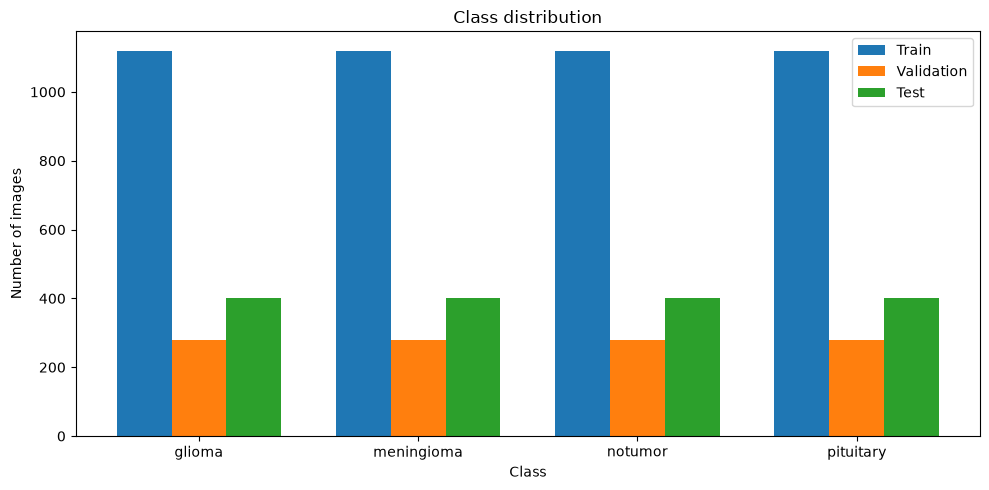

pituitary 1400
notumor 1400
glioma 1400
meningioma 1400
pituitary 400
notumor 400
glioma 400
meningioma 400


In [61]:
train_counts = np.bincount(np.array(raw_train.targets)[train_indices], minlength=len(class_names))
val_counts = np.bincount(np.array(raw_train.targets)[val_indices], minlength=len(class_names))
test_counts = np.bincount(np.array(raw_test.targets), minlength=len(class_names))

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, train_counts, width, label="Train")
ax.bar(x, val_counts, width, label="Validation")
ax.bar(x + width, test_counts, width, label="Test")

ax.set_title("Class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of images")
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()

plt.tight_layout()
plt.show()

for folder in [TRAIN_DIR, TEST_DIR]:
    for subfolder in folder.iterdir():
        print(subfolder.name, len(list(subfolder.iterdir())))  

## Train / Validation Split

The original training dataset is divided into two subsets:

- **80% training set** — used to update the model parameters,
- **20% validation set** — used to monitor model performance during training.

The original Kaggle testing dataset remains separate and will only be used for the final evaluation.

A stratified split is used so that the proportions of the four classes remain approximately the same in both the training and validation sets.

## Image Transformations
data argumentaion - only on train dataset

In [41]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean= MEAN, std= STD)
])  


## Datasets + Subsets

In [51]:
train_data_all = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_data_all = datasets.ImageFolder(TRAIN_DIR, transform=eval_transform)
test_data = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

train_data = Subset(train_data_all, train_indices)
val_data = Subset(val_data_all, val_indices)


## DataLoaders

PyTorch `DataLoader` objects prepare the datasets for neural network training.

Instead of sending all images to the model at once, the dataset is divided into smaller groups called **batches**.

For the training set:

- `batch_size` determines the number of images in one batch,
- `shuffle=True` changes the image order at the beginning of every epoch.

For validation and test datasets, shuffling is unnecessary because the model parameters are no longer being updated.

In [52]:
train_loader = DataLoader(
    train_data, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(val_data, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_data, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS
)


Kształt obrazów: torch.Size([32, 3, 224, 224]) | etykiet: torch.Size([32])


## Data Pipeline Sanity Check


For image classification in PyTorch, an image batch usually has the following structure:
[batch_size, channels, height, width]

In [57]:
images, labels = next(iter(train_loader))
print("Images shape:", images.shape, "| Labels shape", labels.shape)

Images shape: torch.Size([32, 3, 224, 224]) | Labels shape torch.Size([32])


## Visualizing a Training batch

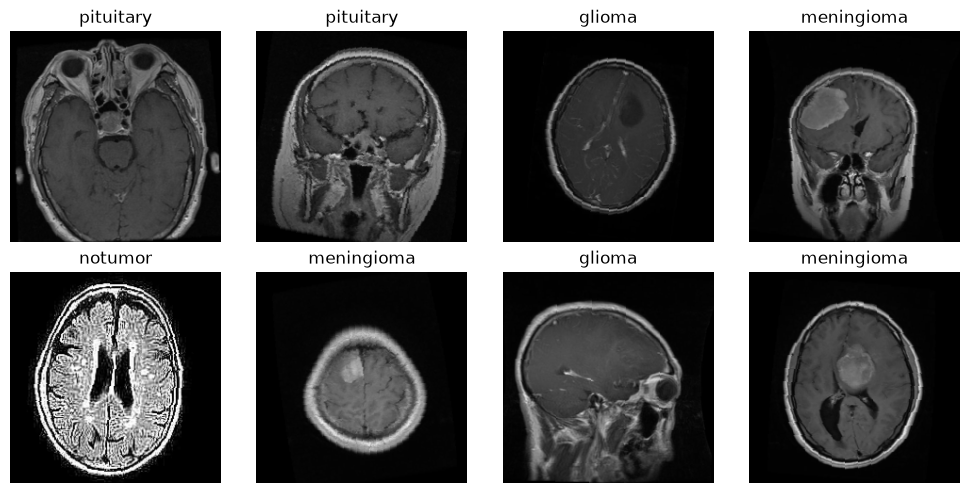

In [59]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, img, label in zip(axes.flat, images[:8], labels[:8]):
    # Undo normalization for visualization only.
    shown = img * STD + MEAN
    ax.imshow(shown.clamp(0, 1).permute(1, 2, 0))
    ax.set_title(class_names[label.item()])
    ax.axis("off")
plt.tight_layout()
plt.show()

# Part II — Convolutional Neural Network

## CNN Architecture

A Convolutional Neural Network is designed to automatically learn useful visual features from images.

The model will consist of two main parts:

1. **Feature extraction**
   - convolutional layers,
   - activation functions,
   - pooling layers.

2. **Classification**
   - flattened feature representation,
   - fully connected layers,
   - final output layer with one output for each class.

The model will predict one of four possible brain MRI classes.